In [1]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this sampleset
wildcode = load_dataset("regularpooria/wildcode")

/home/regularpooria/Projects/WildCode/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# You need to do this only once
#!git clone https://github.com/mazen160/secrets-patterns-db.git

In [3]:
patterns_file_path = "../../secrets-patterns-db/db/rules-stable.yml"
output_file = "regex_results.csv"

In [4]:
import yaml, re
def load_patterns_from_yaml(path: str):
    with open(path, "r", encoding="utf-8") as f:
        raw = yaml.safe_load(f)
    patterns = []
    for entry in (raw.get("patterns") or []):
        if not isinstance(entry, dict):
            continue
        p = entry.get("pattern") or entry
        if not p:
            continue
        name = p.get("name") or "<unnamed>"
        regex = p.get("regex")
        confidence = p.get("confidence", None)
        if regex:
            patterns.append({"name": name, "regex": regex, "confidence": confidence})
    return patterns


def prepare_patterns(yaml_path: str):
    _PATTERNS = load_patterns_from_yaml(yaml_path)
    _COMPILED = []
    for p in _PATTERNS:
        # compile — you may add flags here (re.IGNORECASE) if you want case-insensitive
        try:
            cre = re.compile(p["regex"])
        except re.error as e:
            raise RuntimeError(f"Bad regex for pattern '{p['name']}': {p['regex']} -> {e}")
        _COMPILED.append((p["name"], cre, p.get("confidence")))

    return _COMPILED

In [5]:
# patterns = load_patterns_from_yaml(patterns_file_path)
patterns = prepare_patterns(patterns_file_path)

In [6]:
patterns[0]

('AWS API Gateway',
 re.compile(r'[0-9a-z]+.execute-api.[0-9a-z._-]+.amazonaws.com', re.UNICODE),
 'low')

In [7]:
def run_regex_on_data(sample):
  code = sample["code"]
  matches = []
  for pat in patterns:
    for m in pat[1].finditer(code):
      matches.append({
          "pattern": pat[0],
          "match": m.group(0),
          "start": m.start(),
          "end": m.end(),
          "confidence": pat[2]
      })
  sample["matches"] = matches
  return sample

In [8]:
import os
cpu_cores = os.cpu_count()

In [9]:
from datasets import Features, Sequence, Value

# Define the schema for your matches - using a list of structs
features = Features({
    **wildcode['train'].features,  # Keep existing features
    "matches": [{
        "pattern": Value("string"),
        "match": Value("string"),
        "start": Value("int64"),
        "end": Value("int64"),
        "confidence": Value("string")
    }]
})

In [10]:
wildcode = wildcode.map(run_regex_on_data, features=features, num_proc=cpu_cores)

In [11]:
def fix_pattern_matching(sample):
  for index, _match in enumerate(sample["matches"]):
      new_line_end = sample["code"].find("\n", _match["start"])
      sample["matches"][index]["match"] = sample["code"][_match["start"]:new_line_end]
      sample["matches"][index]["end"] = new_line_end
    
  return sample

In [12]:
wildcode = wildcode.map(fix_pattern_matching, num_proc=cpu_cores)

# Generating overall stats

In [13]:
wildcode

DatasetDict({
    train: Dataset({
        features: ['conversation_hash', 'code_index', 'language', 'libraries', 'code', 'filename', 'matches'],
        num_rows: 155725
    })
})

In [14]:
import pandas as pd

# Create an empty dictionary to accumulate data by conversation_hash
combined_data = {}

# Loop over the Hugging Face dataset rows
for item in wildcode["train"]:
    conv_hash = item["conversation_hash"]

    # Initialize if this conversation hasn't been seen yet
    if conv_hash not in combined_data:
        combined_data[conv_hash] = {
            "conversation_hash": conv_hash,
            "language": item["language"],
            "libraries": set(item["libraries"] or []),
            "code": [item["code"]],
            "filename": set([item["filename"]]),
            "matches": list(item["matches"] or []),
        }
    else:
        # Merge / append new data
        combined_data[conv_hash]["libraries"].update(item["libraries"] or [])
        combined_data[conv_hash]["code"].append(item["code"])
        combined_data[conv_hash]["filename"].add(item["filename"])
        combined_data[conv_hash]["matches"].extend(item["matches"] or [])

# Convert back to DataFrame
wildcode_conversations = pd.DataFrame.from_dict(combined_data, orient="index").reset_index(drop=True)

# Convert sets and lists into readable formats
wildcode_conversations["libraries"] = wildcode_conversations["libraries"].apply(list)
wildcode_conversations["filename"] = wildcode_conversations["filename"].apply(list)
wildcode_conversations["code"] = wildcode_conversations["code"].apply(lambda x: "\n\n# ----- next snippet -----\n\n".join(x))

print(f"Total conversations: {len(wildcode_conversations)}")
wildcode_conversations.head()


Total conversations: 57409


,conversation_hash,language,libraries,code,filename,matches
0,49f2df1f57031159e37e648404f84d0b,ARM Assembly,[],RAIDZ1_1 RAIDZ1_2 RAIDZ1_...,"[49f2df1f57031159e37e648404f84d0b_3.s, 49f2df1...",[]
1,b3149d92146d6bc242798a5ae0301503,ARM Assembly,[the],section .data\n\nprompt db 'Enter three number...,"[b3149d92146d6bc242798a5ae0301503_0.pl, b3149d...",[]
2,e0b745323b7e4e13b89938befd0eb951,ARM Assembly,[],"section .data\nin_format db ""%d%d%d"", 0\nout_f...","[e0b745323b7e4e13b89938befd0eb951_2.s, e0b7453...",[]
3,da771b58996564e863e383c656f39880,ARM Assembly,[],..\n..\n..\n.rg\n.\nlb\n.yl\n..lg\n.yl\n.kw\n....,"[da771b58996564e863e383c656f39880_0.pas, da771...",[]
4,33892ca78c6f95eefeb081c2fffa1257,ARM Assembly,[],A B\n1 Nama Kota\n2 Budi J...,"[33892ca78c6f95eefeb081c2fffa1257_11.s, 33892c...",[]


In [15]:
wildcode_conversations_with_matches = wildcode_conversations[wildcode_conversations["matches"].apply(lambda x: len(x)> 0)]

In [16]:
import pandas as pd
from collections import Counter

# For each conversation, collect unique patterns appearing in its matches
conversation_patterns = (
    wildcode_conversations_with_matches["matches"]
    .apply(lambda matches: {m["pattern"] for m in matches if isinstance(m, dict) and "pattern" in m})
)

# Flatten across conversations and count how many conversations had each pattern
pattern_counter = Counter()
for patterns in conversation_patterns:
    pattern_counter.update(patterns)

# Convert to DataFrame for easy viewing
pattern_df = (
    pd.DataFrame(pattern_counter.items(), columns=["pattern", "num_conversations"])
    .sort_values("num_conversations", ascending=False)
    .reset_index(drop=True)
)

pattern_df.head(20)


,pattern,num_conversations
0,api_key,463
1,access_token,129
2,JDBC Connection String,95
3,Password in URL,94
4,Generic - 1376,85
5,Uri,79
6,client_secret,45
7,api_secret,41
8,Generic - 1693,30
9,Bearer token,25


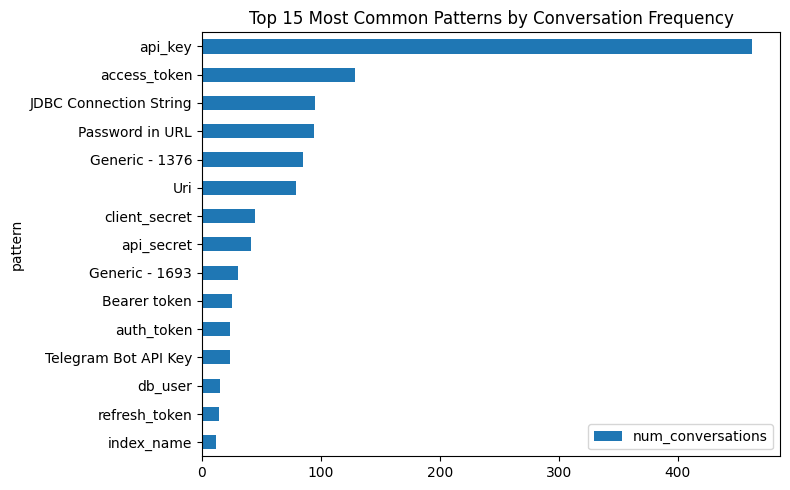

In [17]:
import matplotlib.pyplot as plt

top_n = 15
pattern_df.head(top_n).plot(
    x="pattern",
    y="num_conversations",
    kind="barh",
    figsize=(8,5),
    title=f"Top {top_n} Most Common Patterns by Conversation Frequency"
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Finding secrets

In [18]:
api_keywords = [
    # General auth / secret terms
    "api_key", "apikey", "api-key", "api_key_id", "api_secret", "api_secret_key",
    "secret", "secret_key", "secretkey", "private_key", "privatekey", "private-key",
    "access_token", "accesstoken", "auth_token", "authtoken", "bearer_token",
    "token", "refresh_token", "id_token", "jwt_token", "jwt_secret",
    
    # OAuth / Client credentials
    "client_id", "clientid", "client_key", "client_secret", "clientsecret",
    "consumer_key", "consumer_secret",
    
    # Cloud providers
    "aws_access_key", "aws_secret_key", "aws_session_token", "aws_secret_access_key",
    "gcp_api_key", "google_api_key", "google_cloud_api_key",
    "azure_client_id", "azure_client_secret", "azure_tenant_id",
    
    # GitHub / GitLab / VCS tokens
    "github_token", "github_pat", "gitlab_token", "gitlab_private_token",
    
    # Service-specific
    "slack_token", "discord_token", "bot_token", "firebase_api_key",
    "stripe_secret_key", "stripe_publishable_key", "sendgrid_api_key",
    "twilio_auth_token", "mapbox_token", "openai_api_key",
    
    # Environment or config-related
    "auth_key", "authentication_key", "authorization_token", "service_account_key",
    "credential", "credentials", "integration_token", "webhook_secret",
    "security_token", "session_token", "password", "passphrase"
]

In [19]:
def run_keyword_on_dataset(sample):
    for _match in sample["matches"]:
        # for key in banned_words:
        #     if key.lower() in _match["match"].lower():
        #         return False
        for key in api_keywords:
            if key.lower() in _match["match"].lower():
                return True
    return False

In [20]:
wildcode_api_keys = wildcode.filter(run_keyword_on_dataset)
len(wildcode_api_keys["train"])

1380

In [21]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent)) 

In [22]:
from utils.secret_classifier_utils.run_custom_lgb_model import SecretClassifier

classifier = SecretClassifier(
    model_path='../../utils/secret_classifier_utils/secret_classifier_model.txt',
    metadata_path='../../utils/secret_classifier_utils/model_metadata.json'
)

Loading model from ../../utils/secret_classifier_utils/secret_classifier_model.txt...
Loading metadata from ../../utils/secret_classifier_utils/model_metadata.json...
✓ Model loaded successfully
  Features: 44
  Thresholds: {'high_confidence_real': 0.5, 'medium_confidence': 0.49, 'high_confidence_placeholder': 0.48}


In [23]:
def run_through_tree_model(sample):
    for _match in sample["matches"]:
        if classifier.classify(_match["match"])["label"] == "REAL":
            return True
    return False

In [24]:
wildcode_api_keys = wildcode_api_keys.filter(run_through_tree_model)
len(wildcode_api_keys["train"])

209

In [25]:
wildcode_api_keys["train"][70]

{'conversation_hash': '04059bc225c9841cd59d35924f4827b8',
 'code_index': 2,
 'language': 'Python',
 'libraries': ['BytesIO',
  'Image',
  'PIL',
  'altair',
  'datetime',
  'groupby',
  'io',
  'itertools',
  'json',
  'pandas',
  'requests',
  'streamlit'],
 'code': 'import streamlit as st\nimport pandas as pd\nimport requests\nimport json\nfrom PIL import Image, ImageOps\nfrom io import BytesIO\nfrom itertools import groupby\nimport datetime\nimport altair as alt\n\naccess_token = "EAAIui8JmOHYBAESXLZAnsSRe4OITHYzy3Q5osKgMXGRQnoVMtiIwJUonFjVHEjl9EZCEmURy9I9S9cnyFUXBquZCsWnGx1iJCYTvkKuUZBpBwwSceZB0ZB6YY9B83duIwZCoOlrOODhnA3HLLGbRKGPJ9hbQPLCrkVbc5ibhE43wIAinV0gVkJ30x4UEpb8fXLD8z5J9EYrbQZDZD"\naccount_id = "17841458386736965"\n\ndef load_media_info(access_token, account_id):\n    base_url = f"https://graph.facebook.com/v11.0/{account_id}/media"\n    params = {\n        "fields": "id,media_type,media_url,thumbnail_url,permalink,caption,timestamp,like_count,comments_count,insights.metric(

In [26]:
wildcode_api_keys["train"].to_pandas()[["conversation_hash","matches"]].to_csv("../../results/regex_secret_results.csv")

In [27]:
import pandas as pd

# Create an empty dictionary to accumulate data by conversation_hash
combined_data = {}

# Loop over the Hugging Face dataset rows
for item in wildcode_api_keys["train"]:
    conv_hash = item["conversation_hash"]
    # Initialize if this conversation hasn't been seen yet
    if conv_hash not in combined_data:
        combined_data[conv_hash] = {
            "conversation_hash": conv_hash,
            "language": item["language"],
            "libraries": set(item["libraries"] or []),
            "code": [item["code"]],
            "filename": set([item["filename"]]),
            "matches": list(item["matches"] or []),
        }
    else:
        # Merge / append new data
        combined_data[conv_hash]["libraries"].update(item["libraries"] or [])
        combined_data[conv_hash]["code"].append(item["code"])
        combined_data[conv_hash]["filename"].add(item["filename"])
        combined_data[conv_hash]["matches"].extend(item["matches"] or [])

# Convert back to DataFrame
wildcode_api_keys_conversations = pd.DataFrame.from_dict(combined_data, orient="index").reset_index(drop=True)

# Convert sets and lists into readable formats
wildcode_api_keys_conversations["libraries"] = wildcode_api_keys_conversations["libraries"].apply(list)
wildcode_api_keys_conversations["filename"] = wildcode_api_keys_conversations["filename"].apply(list)
wildcode_api_keys_conversations["code"] = wildcode_api_keys_conversations["code"].apply(lambda x: "\n\n# ----- next snippet -----\n\n".join(x))

print(f"Total conversations: {len(wildcode_api_keys_conversations)}")
wildcode_api_keys_conversations.head()


Total conversations: 111


,conversation_hash,language,libraries,code,filename,matches
0,6f0d8f70b6b12cca6a14576ff4cfd84a,Erlang,[],version: '3.8'\nservices:\n nginx:\n image...,[6f0d8f70b6b12cca6a14576ff4cfd84a_0.erl],"[{'pattern': 'Generic - 1693', 'match': 'PASSW..."
1,81ffecec1bb3d4b0b35517b5d2681462,Erlang,[],"version: ""3""\n\nservices:\n sonarqube:\n i...",[81ffecec1bb3d4b0b35517b5d2681462_0.erl],"[{'pattern': 'Generic - 1693', 'match': 'PASSW..."
2,81eeeaef46e1b5b3897a4540e2bf4a14,Perl,[],docker run -d \\n --name=wg-easy \\n --cap-a...,"[81eeeaef46e1b5b3897a4540e2bf4a14_2.pl, 81eeea...","[{'pattern': 'Generic - 1693', 'match': 'PASSW..."
3,dea3eb7e75b3b5399aad7f51a630cbf3,PowerShell,[],docker run --name some-documentserver -d \\n ...,[dea3eb7e75b3b5399aad7f51a630cbf3_13.ps1],"[{'pattern': 'Generic - 1693', 'match': 'PASSW..."
4,78abb7c68eabdda721edc142908383b4,PowerShell,[],cluster {\n listen: 0.0.0.0:6222\n routes: [...,"[78abb7c68eabdda721edc142908383b4_24.ps1, 78ab...","[{'pattern': 'Password in URL', 'match': 'rout..."


In [28]:
wildcode_api_keys_conversations_with_matches = wildcode_api_keys_conversations[wildcode_api_keys_conversations["matches"].apply(lambda x: len(x)> 0)]

In [29]:
import pandas as pd
from collections import Counter

# For each conversation, collect unique patterns appearing in its matches
conversation_patterns = (
    wildcode_api_keys_conversations_with_matches["matches"]
    .apply(lambda matches: {m["pattern"] for m in matches if isinstance(m, dict) and "pattern" in m})
)

# Flatten across conversations and count how many conversations had each pattern
pattern_counter = Counter()
for patterns in conversation_patterns:
    pattern_counter.update(patterns)

# Convert to DataFrame for easy viewing
pattern_df_api_keys = (
    pd.DataFrame(pattern_counter.items(), columns=["pattern", "num_conversations"])
    .sort_values("num_conversations", ascending=False)
    .reset_index(drop=True)
)

pattern_df_api_keys.head(20)


,pattern,num_conversations
0,api_key,56
1,Password in URL,13
2,access_token,13
3,Generic - 1693,11
4,Uri,11
5,JDBC Connection String,8
6,Generic - 1376,6
7,client_secret,4
8,Telegram Bot API Key,3
9,Bearer token,3


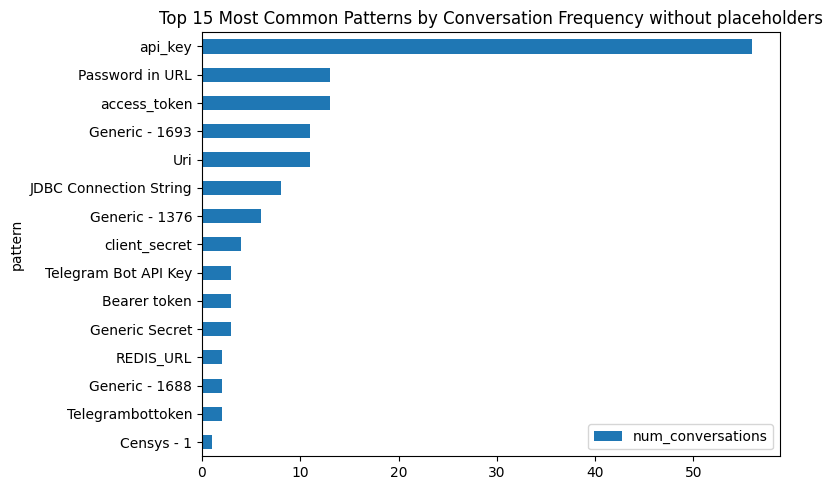

In [30]:
import matplotlib.pyplot as plt

top_n = 15
pattern_df_api_keys.head(top_n).plot(
    x="pattern",
    y="num_conversations",
    kind="barh",
    figsize=(8,5),
    title=f"Top {top_n} Most Common Patterns by Conversation Frequency without placeholders"
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
